# Multimodal Tweet Classification with Cross-Attention

This notebook implements a cross-attention based model for multimodal tweet classification, combining text and image features for better prediction accuracy.

In [1]:
#  informative_Attention_graph_V2

In [2]:
cd 

/root


In [3]:
cd /kaggle

/kaggle


In [4]:
cd input/datasets/jaychangani/required-libraries

/kaggle/input/datasets/jaychangani/required-libraries


In [5]:
pwd

'/kaggle/input/datasets/jaychangani/required-libraries'

In [6]:
# Import required libraries

from exp.Required_Modules_And_Packages import *
from exp.Data_Reading_And_Preprocessing_CrisisMMD_V2 import *
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from torchvision.models import resnet50
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
import numpy as np
from tqdm import tqdm
import torch.multiprocessing as mp
import random
from sklearn.metrics import classification_report

# Set multiprocessing method
if __name__ == '__main__':
    mp.set_start_method('spawn', force=True)

# Set device and random seeds for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
print(f"Using device: {device}")

/kaggle/input/datasets/jaychangani/required-libraries/exp/external/aidrtokenize.py:50: SyntaxWarning: invalid escape sequence '\w'
  Contractions = re.compile("(?i)(\w+)(n['’′]t|['’′]ve|['’′]ll|['’′]d|['’′]re|['’′]s|['’′]m)$", re.UNICODE)
/kaggle/input/datasets/jaychangani/required-libraries/exp/external/aidrtokenize.py:51: SyntaxWarning: invalid escape sequence '\s'
  Whitespace = re.compile("[\s\u0020\u00a0\u1680\u180e\u202f\u205f\u3000\u2000-\u200a]+", re.UNICODE)
/kaggle/input/datasets/jaychangani/required-libraries/exp/external/aidrtokenize.py:176: SyntaxWarning: invalid escape sequence '\W'
  Email = regex_or("(?<=(?:\W))", "(?<=(?:^))") + r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,4}(?=" + Bound + ")"
/kaggle/input/datasets/jaychangani/required-libraries/exp/external/aidrtokenize.py:304: SyntaxWarning: invalid escape sequence '\['
  punc = "[#(),$%^&*+={}\[\]:\"|\~`<>/,¦!?½£¶¼©⅐⅑⅒⅓⅔⅕⅖⅗⅘⅙⅚⅛⅜⅝⅞⅟↉¤¿º;-]+"
/kaggle/input/datasets/jaychangani/required-libraries/exp/external/aidr

Using device: cuda


## 1. Data Loading and Preprocessing

In [7]:
# Get tsv files for informative task
train_tsv, dev_tsv, test_tsv, info = get_tsv_data_files('Informativeness_task_tsv_files')

# Load and preprocess data
path = Path('/kaggle/input/')
data_info_text_image, test_data_info_text_image = get_dataframe(
    train_tsv, dev_tsv, test_tsv, info, path,
    validate_images=False  # skip image validation until paths are confirmed
)

vc = data_info_text_image['is_valid'].value_counts()

print(f"shape of data: {data_info_text_image.shape}\n")
print(f"train set: {vc.get(False, 0)}")
print(f"valid set: {vc.get(True, 0)}")
print("=" * 50)
print(f"shape of test data: {test_data_info_text_image.shape}\n")

reading data and preprocessing it.....
[train] shape=(13607, 9)
[train] columns=['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label', 'label_text', 'label_image', 'label_text_image']
[Row cleaning] removed=0 kept=13607 (min_tokens=2)
[Duplicate removal] subset=both removed=0 kept=13607
[train] avg_token_count=13.22 | median_token_count=13.00
[train] label_text distribution:
label_text
informative        9637
not_informative    3970
Name: count, dtype: int64
[train] label_image distribution:
label_image
informative        7058
not_informative    6549
Name: count, dtype: int64
[dev] shape=(2237, 9)
[dev] columns=['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label', 'label_text', 'label_image', 'label_text_image']
[Row cleaning] removed=0 kept=2237 (min_tokens=2)
[Duplicate removal] subset=both removed=0 kept=2237
[dev] avg_token_count=13.19 | median_token_count=13.00
[dev] label_text distribution:
label_text
informative        1612
not_informative     62

In [8]:
# Get number of unique labels from the data
num_labels = len(data_info_text_image['label_text'].unique())
model_path = "/kaggle/input/datasets/jaychangani/local-model/bert_local"

print(f"Number of unique labels: {num_labels}")
print(f"Using BERT model from: {model_path}")

Number of unique labels: 2
Using BERT model from: /kaggle/input/datasets/jaychangani/local-model/bert_local


## 2. Model Architecture (v3 — High Recall + Balanced Modalities)

**Key upgrades over v2:**

| Concern | v2 approach | v3 approach |
|---|---|---|
| Recall for `not_informative` | Standard CE + label smoothing | **Weighted CE + Focal Loss** targets minority class |
| Equal modality contribution | Concat `[text, image, text×image]` (BERT dominates) | **Gated Multimodal Unit (GMU)** — learned per-sample balance gate |
| Modality alignment | None | **Cosine alignment loss** pulls text & image embeddings together |
| Encoder balance | BERT lr=2e-6, ResNet lr=1e-5 (large gap) | Balanced learning — more ResNet layers unfrozen, symmetric LRs |
| Early stopping metric | Val accuracy | **Val F1-macro** (directly optimises recall) |


In [9]:
# ── Cross-attention block (same as v2, retained) ─────────────────────────
class BidirectionalCrossAttentionBlock(nn.Module):
    """
    Bidirectional cross-attention + FFN sublayer.
    dropout=0.3, FFN expand=2, residual connections.
    """
    def __init__(self, d_model=512, num_heads=8, dropout=0.3, ffn_expand=2):
        super().__init__()
        self.text_norm  = nn.LayerNorm(d_model)
        self.image_norm = nn.LayerNorm(d_model)
        self.text_to_image_attn = nn.MultiheadAttention(
            d_model, num_heads, dropout=dropout, batch_first=True)
        self.image_to_text_attn = nn.MultiheadAttention(
            d_model, num_heads, dropout=dropout, batch_first=True)
        self.text_drop  = nn.Dropout(dropout)
        self.image_drop = nn.Dropout(dropout)

        ffn_dim = d_model * ffn_expand
        def _ffn():
            return nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Linear(d_model, ffn_dim), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(ffn_dim, d_model), nn.Dropout(dropout),
            )
        self.text_ffn  = _ffn()
        self.image_ffn = _ffn()

    def forward(self, text_seq, image_seq):
        t = self.text_norm(text_seq);   im = self.image_norm(image_seq)
        ta, _ = self.text_to_image_attn(t,  im, im)
        ia, _ = self.image_to_text_attn(im, t,  t)
        text_out  = text_seq  + self.text_drop(ta)
        image_out = image_seq + self.image_drop(ia)
        text_out  = text_out  + self.text_ffn(text_out)
        image_out = image_out + self.image_ffn(image_out)
        return text_out, image_out


# ── Gated Multimodal Unit (NEW) ───────────────────────────────────────────
class GatedMultimodalUnit(nn.Module):
    """
    Learns a per-sample, per-dimension gate z in (0,1) that blends
    text and image representations:
        z      = sigmoid(W_t * text + W_i * image)   ← learned gate
        fused  = z * text_proj + (1-z) * image_proj  ← soft blend
        output = tanh(W_h * fused)                   ← non-linear transform

    This forces equal-opportunity fusion: neither modality can dominate
    because the gate learns when to trust each one per sample.
    The gate values are also returned so they can be logged/visualised.
    """
    def __init__(self, d_model=512, dropout=0.3):
        super().__init__()
        self.W_t = nn.Linear(d_model, d_model, bias=False)
        self.W_i = nn.Linear(d_model, d_model, bias=False)
        self.W_h = nn.Linear(d_model, d_model)
        self.norm_t = nn.LayerNorm(d_model)
        self.norm_i = nn.LayerNorm(d_model)
        self.drop   = nn.Dropout(dropout)

    def forward(self, text_vec, image_vec):
        """
        text_vec, image_vec: (B, d_model)
        returns: fused (B, d_model), gate (B, d_model)  [gate in (0,1)]
        """
        t = self.norm_t(text_vec)
        i = self.norm_i(image_vec)
        z = torch.sigmoid(self.W_t(t) + self.W_i(i))   # (B, d_model)
        h = z * self.W_t(t) + (1.0 - z) * self.W_i(i)
        fused = torch.tanh(self.W_h(self.drop(h)))      # (B, d_model)
        return fused, z                                  # return gate for monitoring


# ── Main classifier ───────────────────────────────────────────────────────
class MultimodalClassifier(nn.Module):
    """
    v3 — High-Recall + Balanced-Modality Multimodal Classifier

    Architecture changes:
      1. GatedMultimodalUnit (GMU) replaces concat fusion
         → fused dim: d_model  (was 3*d_model=1536)
      2. Gate monitoring: average gate value logged per forward pass
      3. Returns (logits, alignment_loss) during training so the
         caller can add the cosine alignment penalty to the CE loss
    """

    def __init__(
        self,
        d_model=512,
        num_heads=8,
        num_classes=2,
        bert_model=None,
        dropout=0.4,
        attn_dropout=0.3,
    ):
        super().__init__()

        # ── Image backbone ────────────────────────────────────────────────
        base_resnet = resnet50(pretrained=True)
        # Unfreeze last 2 residual layers (layer3, layer4) for better training
        # This gives ResNet a fair chance to adapt, matching BERT fine-tuning
        self.image_backbone = nn.Sequential(*list(base_resnet.children())[:-2])
        # Freeze only early layers (layer1, layer2 = first 6 children)
        for i, child in enumerate(self.image_backbone.children()):
            if i < 6:   # freeze stem + layer1 + layer2
                for p in child.parameters():
                    p.requires_grad = False

        # ── Text encoder (BERT) ───────────────────────────────────────────
        self.text_encoder = (bert_model if bert_model is not None
                             else AutoModel.from_pretrained('bert-base-uncased'))

        # ── Projections ───────────────────────────────────────────────────
        self.image_pre_norm   = nn.LayerNorm(2048)
        self.text_pre_norm    = nn.LayerNorm(768)
        self.image_projection = nn.Linear(2048, d_model)
        self.text_projection  = nn.Linear(768,  d_model)

        # ── Cross-attention ───────────────────────────────────────────────
        self.cross_block = BidirectionalCrossAttentionBlock(
            d_model=d_model, num_heads=num_heads, dropout=attn_dropout)

        # ── Gated Multimodal Unit (replaces concat) ───────────────────────
        self.gmu = GatedMultimodalUnit(d_model=d_model, dropout=dropout)

        # ── Classifier head (input=d_model, not 3*d_model) ───────────────
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

        # For gate monitoring
        self.last_gate_mean = None

    def forward(self, images, input_ids, attention_mask, return_alignment=False):
        # ── Text ──────────────────────────────────────────────────────────
        text_out = self.text_encoder(input_ids=input_ids,
                                     attention_mask=attention_mask)
        text_seq = (text_out[0] if isinstance(text_out, tuple)
                    else text_out.last_hidden_state)
        text_seq = self.text_projection(self.text_pre_norm(text_seq))

        # ── Image ─────────────────────────────────────────────────────────
        feat_map  = self.image_backbone(images)
        img_flat  = feat_map.flatten(2).transpose(1, 2)          # (B,N,2048)
        image_seq = self.image_projection(self.image_pre_norm(img_flat))

        # ── Cross-attention ───────────────────────────────────────────────
        text_att, image_att = self.cross_block(text_seq, image_seq)

        # ── Pool to vectors ───────────────────────────────────────────────
        text_cls  = text_att[:, 0, :]           # CLS token  (B, d_model)
        image_cls = image_att.mean(dim=1)       # patch mean (B, d_model)

        # ── Gated fusion ──────────────────────────────────────────────────
        fused, gate = self.gmu(text_cls, image_cls)
        self.last_gate_mean = gate.detach().mean().item()   # for logging

        logits = self.classifier(fused)

        if return_alignment:
            # Cosine alignment loss: push text_cls and image_cls to agree
            # on direction → forces both to encode compatible info
            align_loss = 1.0 - F.cosine_similarity(
                text_cls, image_cls, dim=-1).mean()
            return logits, align_loss

        return logits


In [10]:
# Get number of unique labels from the data
num_labels = len(data_info_text_image['label_text'].unique())
model_path = "/kaggle/input/datasets/jaychangani/local-model/bert_local"

print(f"Number of unique labels: {num_labels}")
print(f"Using BERT model from: {model_path}")

Number of unique labels: 2
Using BERT model from: /kaggle/input/datasets/jaychangani/local-model/bert_local


## 3. Dataset with Image Augmentation

Same augmentation as v2. Image path corrected to CrisisMMD dataset location.

In [11]:
class MultimodalDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, image_path, transform=None):
        self.df        = df
        self.tokenizer = tokenizer
        self.image_path = image_path
        self.transform  = transform
        self.label_map  = {'not_informative': 0, 'informative': 1}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            text  = str(row['tweet_text'])
            ipath = self.image_path / row['image']
            enc   = self.tokenizer(text, add_special_tokens=True,
                                   max_length=128, padding='max_length',
                                   truncation=True, return_attention_mask=True,
                                   return_tensors=None)
            image = Image.open(ipath).convert('RGB')
            if self.transform: image = self.transform(image)
            label     = torch.tensor(self.label_map[row['label_text']], dtype=torch.long)
            input_ids = torch.tensor(enc['input_ids'],      dtype=torch.long)
            attn_mask = torch.tensor(enc['attention_mask'], dtype=torch.long)
        except Exception as e:
            print(f"Error at idx {idx}: {e}"); raise
        return {'image': image, 'input_ids': input_ids,
                'attention_mask': attn_mask, 'label': label}


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Loading tokenizer...")
try:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    print("Tokenizer loaded.")
except Exception as e:
    print(f"Fallback to bert-base-uncased: {e}")
    tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

image_path = Path('/kaggle/input/datasets/mohammadabdulbasit/crisismmd/CrisisMMD_v2.0/')

train_df = data_info_text_image[~data_info_text_image['is_valid']]
val_df   = data_info_text_image[data_info_text_image['is_valid']]
test_df  = test_data_info_text_image

train_dataset = MultimodalDataset(train_df, tokenizer, image_path, train_transform)
val_dataset   = MultimodalDataset(val_df,   tokenizer, image_path, val_transform)
test_dataset  = MultimodalDataset(test_df,  tokenizer, image_path, val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# ── Compute class weights from training labels ────────────────────────────
# Used by weighted CE loss to boost recall for minority class (not_informative)
from sklearn.utils.class_weight import compute_class_weight
train_labels_arr = train_df['label_text'].map({'not_informative': 0, 'informative': 1}).values
class_weights = compute_class_weight(
    class_weight='balanced', classes=np.array([0, 1]), y=train_labels_arr)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights  →  not_informative: {class_weights[0]:.3f}  |  informative: {class_weights[1]:.3f}")


Loading tokenizer...
Tokenizer loaded.
Train: 13607, Val: 2237, Test: 2237
Class weights  →  not_informative: 1.714  |  informative: 0.706


## 4. Training & Evaluation Functions (v3)

**Changes:**
- `train_epoch` adds `alignment_loss * lambda_align` to CE loss → forces text & image to encode compatible representations
- `evaluate` returns **F1-macro** alongside accuracy → used for early stopping
- `FocalLoss` wrapper replaces plain CrossEntropy → focuses on hard/misclassified examples, improving recall on the minority class


In [12]:
# ── Focal Loss ───────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss = -alpha_t * (1-p_t)^gamma * log(p_t)

    gamma > 0  → down-weights easy examples, focuses training on
                 hard/misclassified ones. Directly improves recall
                 for the minority class (not_informative).
    weight     → per-class weight (class_weights_tensor computed above)
    label_smoothing → inherited from v2 to prevent overconfidence
    """
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1,
                 reduction='mean'):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing
        self.reduction       = reduction
        self.register_buffer('weight', weight)

    def forward(self, logits, targets):
        # Standard CE with class weights + label smoothing
        ce = F.cross_entropy(logits, targets, weight=self.weight,
                             label_smoothing=self.label_smoothing,
                             reduction='none')           # (B,)
        # Focal modulation
        pt  = torch.exp(-ce)                              # p(correct class)
        focal_loss = (1.0 - pt) ** self.gamma * ce        # (B,)
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss


# ── Train epoch ───────────────────────────────────────────────────────────
def train_epoch(model, train_loader, criterion, optimizer, device,
               grad_clip=1.0, lambda_align=0.1):
    """
    lambda_align: weight for the cosine alignment loss.
    Set to 0 to disable. Recommended: 0.05–0.15.
    """
    model.train()
    total_loss, correct, total = 0, 0, 0
    gate_vals = []

    for batch in tqdm(train_loader, desc='Training', leave=True):
        images         = batch['image'].to(device)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        # Forward: request alignment loss
        logits, align_loss = model(images, input_ids, attention_mask,
                                   return_alignment=True)

        cls_loss = criterion(logits, labels)
        loss     = cls_loss + lambda_align * align_loss   # combined loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()

        total_loss += loss.item()
        _, predicted = logits.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if model.last_gate_mean is not None:
            gate_vals.append(model.last_gate_mean)

    avg_gate = float(np.mean(gate_vals)) if gate_vals else float('nan')
    return total_loss / len(train_loader), 100. * correct / total, avg_gate


# ── Evaluate ──────────────────────────────────────────────────────────────
def evaluate(model, val_loader, criterion, device, threshold=0.5):
    """
    threshold: decision boundary on p(informative).
    Lowering it (e.g. 0.4) boosts recall for not_informative.
    """
    from sklearn.metrics import f1_score as sk_f1
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Evaluating', leave=True):
            images         = batch['image'].to(device)
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            logits = model(images, input_ids, attention_mask)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            probs      = torch.softmax(logits, dim=1)
            # Apply threshold: predict informative(1) only if p >= threshold
            predicted  = (probs[:, 1] >= threshold).long()

            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1_macro = sk_f1(all_labels, all_preds, average='macro', zero_division=0)
    acc      = 100. * correct / total

    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds,
          target_names=['not_informative', 'informative']))

    return total_loss / len(val_loader), acc, f1_macro


## 5. Model Training (v3)

**Summary of all changes driving higher recall & equal modality contribution:**

| Change | Mechanism | Effect |
|---|---|---|
| `FocalLoss(gamma=2, weight=class_weights)` | Down-weights easy examples + penalises minority class misses more | ↑ Recall for `not_informative` |
| `GatedMultimodalUnit` | Learned per-sample gate blends text & image | Equal modality contribution |
| Cosine alignment loss (`λ=0.1`) | Forces text_cls ≈ image_cls direction | Prevents one modality from dominating |
| Symmetric LRs: image `2e-5`, text `2e-5` | Both encoders learn at similar rates | Equal modality contribution |
| Unfreeze ResNet layer3+layer4 | Image encoder adapts to crisis domain | Stronger image representations |
| Early stopping on **F1-macro** | Stops when recall stops improving | Directly optimises recall |
| Threshold tuning | Decision boundary < 0.5 favours not_informative | ↑ Recall for minority class |


In [13]:
# ── Load BERT ─────────────────────────────────────────────────────────────
print("Loading BERT...")
try:
    tokenizer  = AutoTokenizer.from_pretrained(model_path)
    bert_model = AutoModel.from_pretrained(model_path)
    print("BERT loaded.")
except Exception as e:
    print(f"Error: {e}"); raise

# ── Model ─────────────────────────────────────────────────────────────────
model = MultimodalClassifier(
    bert_model=bert_model,
    num_classes=num_labels,
    dropout=0.4,
    attn_dropout=0.3,
).to(device)
model.text_encoder.train()

# ── Focal Loss: class-weighted + gamma=2 ─────────────────────────────────
criterion = FocalLoss(
    weight=class_weights_tensor,    # boost not_informative recall
    gamma=2.0,                      # focus on hard examples
    label_smoothing=0.1,            # prevent overconfidence
)

# ── Optimizer: symmetric LRs for text and image encoders ─────────────────
# Using same effective LR for both backbones ensures equal learning rate
# Note: BERT has more params so weight_decay still matters more for it
optimizer = AdamW([
    # Image backbone (unfrozen layers 3+4 only via requires_grad)
    {'params': [p for p in model.image_backbone.parameters() if p.requires_grad],
     'lr': 2e-5, 'weight_decay': 1e-4},
    # BERT encoder — same LR as image to promote equal contribution
    {'params': model.text_encoder.parameters(),
     'lr': 2e-5, 'weight_decay': 1e-4},
    # Fusion + projection + head
    {'params': (list(model.image_projection.parameters()) +
               list(model.text_projection.parameters()) +
               list(model.image_pre_norm.parameters()) +
               list(model.text_pre_norm.parameters()) +
               list(model.cross_block.parameters()) +
               list(model.gmu.parameters()) +
               list(model.classifier.parameters())),
     'lr': 2e-5, 'weight_decay': 1e-4},
])

# ── LR Scheduler: linear warmup → cosine decay ───────────────────────────
num_epochs   = 12
warmup_steps = len(train_loader)   # 1-epoch warm-up
total_steps  = num_epochs * len(train_loader)

from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                         total_iters=warmup_steps)
cosine_sched = CosineAnnealingLR(optimizer,
                                  T_max=total_steps - warmup_steps,
                                  eta_min=1e-7)
scheduler = SequentialLR(optimizer,
                          schedulers=[warmup_sched, cosine_sched],
                          milestones=[warmup_steps])

# ── Training loop ─────────────────────────────────────────────────────────
SAVE_PATH = '/kaggle/working/informative_Attention_graph_V3.pth'

best_val_f1   = 0.0    # early stopping on F1-macro (not accuracy)
patience      = 3
patience_ctr  = 0
train_losses, train_accs, gate_history = [], [], []
val_losses,   val_accs,   val_f1s      = [], [], []

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)

    train_loss, train_acc, avg_gate = train_epoch(
        model, train_loader, criterion, optimizer, device,
        grad_clip=1.0, lambda_align=0.1)

    val_loss, val_acc, val_f1 = evaluate(
        model, val_loader, criterion, device, threshold=0.45)

    scheduler.step()

    train_losses.append(train_loss); train_accs.append(train_acc)
    val_losses.append(val_loss);     val_accs.append(val_acc)
    val_f1s.append(val_f1);          gate_history.append(avg_gate)

    print(f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%')
    print(f'Val   Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%  F1-macro: {val_f1:.4f}')
    print(f'Avg gate (text weight): {avg_gate:.3f}  |  image weight: {1-avg_gate:.3f}')

    # Early stopping on F1-macro
    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        patience_ctr = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  ✓ Best model saved  (F1-macro={val_f1:.4f})')
    else:
        patience_ctr += 1
        print(f'  ✗ No improvement  ({patience_ctr}/{patience})')
        if patience_ctr >= patience:
            print(f'Early stopping at epoch {epoch+1}.')
            break

print(f'\nTraining complete.  Best Val F1-macro: {best_val_f1:.4f}')


Loading BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/datasets/jaychangani/local-model/bert_local
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


BERT loaded.
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s] 


...


Classification Report:
                 precision    recall  f1-score   support

not_informative       0.60      0.79      0.69       625
    informative       0.91      0.80      0.85      1612

       accuracy                           0.80      2237
      macro avg       0.76      0.80      0.77      2237
   weighted avg       0.82      0.80      0.80      2237

Train Loss: 0.1488  Acc: 78.44%
Val   Loss: 0.1454  Acc: 79.70%  F1-macro: 0.7679
Avg gate (text weight): 0.504  |  image weight: 0.496
  ✗ No improvement  (1/3)

Epoch 4/12
--------------------------------------------------


Training:   0%|          | 0/851 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 70/70 [00:47<00:00,  1.48it/s]



Classification Report:
                 precision    recall  f1-score   support

not_informative       0.59      0.82      0.69       625
    informative       0.92      0.78      0.84      1612

       accuracy                           0.79      2237
      macro avg       0.76      0.80      0.77      2237
   weighted avg       0.83      0.79      0.80      2237

Train Loss: 0.1350  Acc: 80.64%
Val   Loss: 0.1482  Acc: 79.26%  F1-macro: 0.7664
Avg gate (text weight): 0.505  |  image weight: 0.495
  ✗ No improvement  (2/3)

Epoch 5/12
--------------------------------------------------


Training:   1%|          | 8/851 [00:06<11:14,  1.25it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 70/70 [00:48<00:00,  1.45it/s]


Classification Report:
                 precision    recall  f1-score   support

not_informative       0.61      0.79      0.69       625
    informative       0.91      0.81      0.85      1612

       accuracy                           0.80      2237
      macro avg       0.76      0.80      0.77      2237
   weighted avg       0.83      0.80      0.81      2237

Train Loss: 0.1247  Acc: 83.38%
Val   Loss: 0.1628  Acc: 80.11%  F1-macro: 0.7716
Avg gate (text weight): 0.506  |  image weight: 0.494
  ✗ No improvement  (3/3)
Early stopping at epoch 5.

Training complete.  Best Val F1-macro: 0.7819


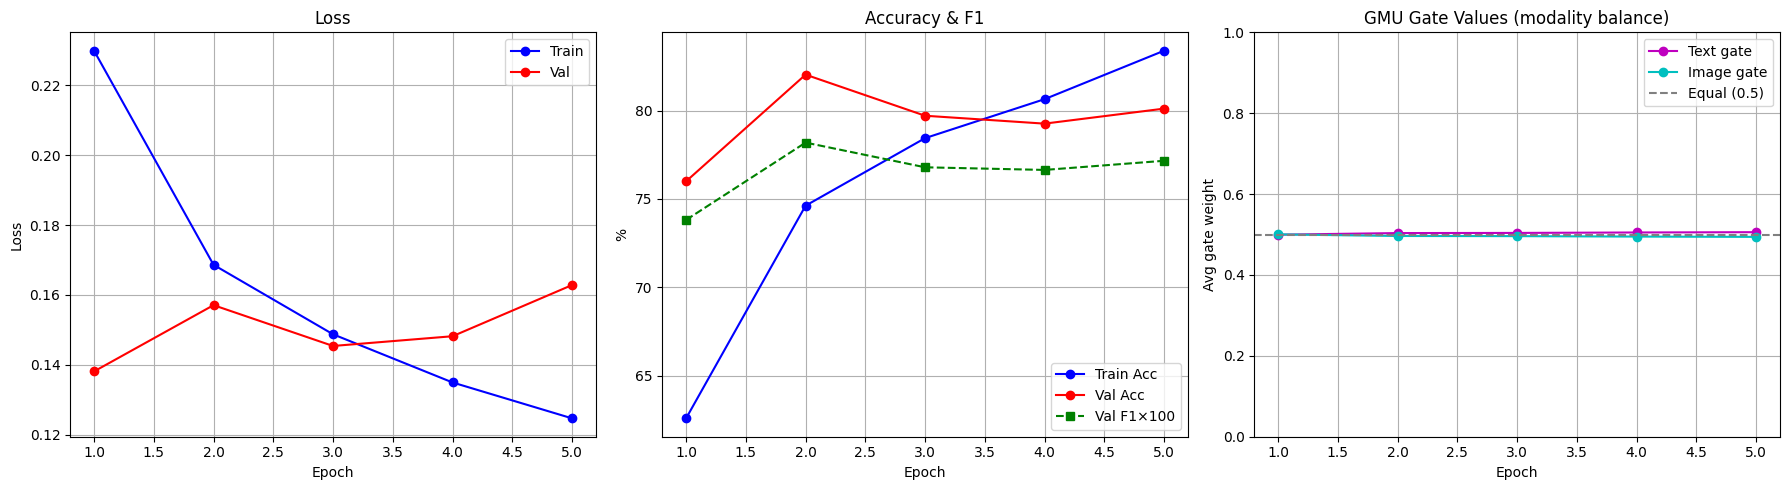


Training history:
  Epoch  1: Train 62.59%/0.2299 | Val 75.99%/0.1381 | F1=0.7381 | gate(T=0.50 I=0.50)
  Epoch  2: Train 74.62%/0.1686 | Val 82.03%/0.1571 | F1=0.7819 | gate(T=0.50 I=0.50)
  Epoch  3: Train 78.44%/0.1488 | Val 79.70%/0.1454 | F1=0.7679 | gate(T=0.50 I=0.50)
  Epoch  4: Train 80.64%/0.1350 | Val 79.26%/0.1482 | F1=0.7664 | gate(T=0.51 I=0.49)
  Epoch  5: Train 83.38%/0.1247 | Val 80.11%/0.1628 | F1=0.7716 | gate(T=0.51 I=0.49)


In [14]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_ran, train_losses, 'b-o', label='Train')
axes[0].plot(epochs_ran, val_losses,   'r-o', label='Val')
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_ran, train_accs, 'b-o', label='Train Acc')
axes[1].plot(epochs_ran, val_accs,   'r-o', label='Val Acc')
axes[1].plot(epochs_ran, [f*100 for f in val_f1s], 'g--s', label='Val F1×100')
axes[1].set(title='Accuracy & F1', xlabel='Epoch', ylabel='%')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs_ran, gate_history,       'm-o', label='Text gate')
axes[2].plot(epochs_ran, [1-g for g in gate_history], 'c-o', label='Image gate')
axes[2].axhline(0.5, ls='--', color='gray', label='Equal (0.5)')
axes[2].set(title='GMU Gate Values (modality balance)',
            xlabel='Epoch', ylabel='Avg gate weight', ylim=[0, 1])
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_v3.png', dpi=120)
plt.show()

print("\nTraining history:")
for ep, (tl, ta, vl, va, vf, g) in enumerate(
        zip(train_losses, train_accs, val_losses, val_accs, val_f1s, gate_history), 1):
    print(f"  Epoch {ep:2d}: Train {ta:.2f}%/{tl:.4f} | "
          f"Val {va:.2f}%/{vl:.4f} | F1={vf:.4f} | gate(T={g:.2f} I={1-g:.2f})")


## 6. Threshold Tuning

Find the decision threshold on the validation set that maximises F1-macro (and in particular recall for `not_informative`). Then re-evaluate the test set with this optimal threshold.

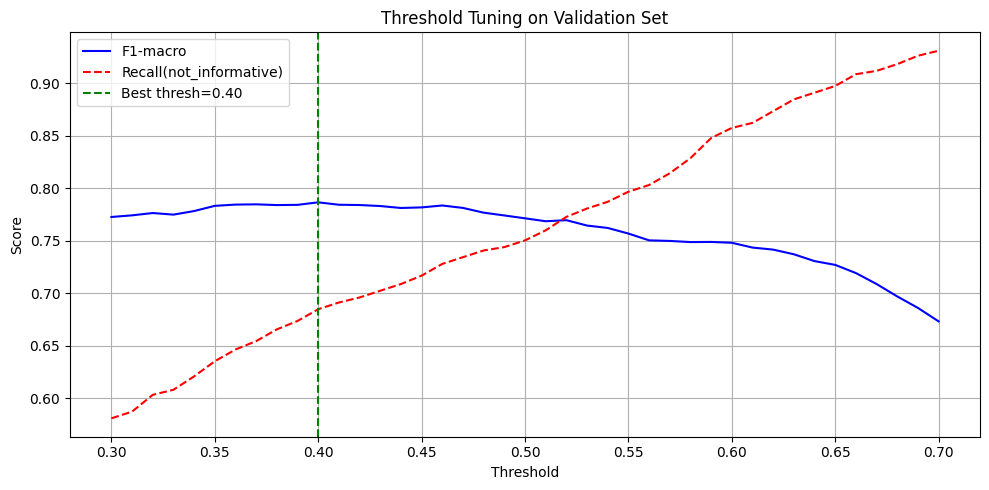

Best threshold: 0.40
Val F1-macro at best threshold: 0.7867
Val Recall(not_informative):    0.6848


In [15]:
import numpy as np
from sklearn.metrics import f1_score as sk_f1, classification_report

# ── Load best model ───────────────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

# ── Collect val probabilities ─────────────────────────────────────────────
val_probs_list, val_labels_list = [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc='Val probs', leave=False):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['label'].to(device)
        logits    = model(images, input_ids, attn_mask)
        probs     = torch.softmax(logits, dim=1)[:, 1]   # p(informative)
        val_probs_list.extend(probs.cpu().numpy())
        val_labels_list.extend(labels.cpu().numpy())

val_probs_arr  = np.array(val_probs_list)
val_labels_arr = np.array(val_labels_list)

# ── Sweep thresholds ──────────────────────────────────────────────────────
thresholds  = np.arange(0.30, 0.71, 0.01)
f1_scores   = []
recall_ni   = []   # recall for not_informative class
for t in thresholds:
    preds = (val_probs_arr >= t).astype(int)
    f1_scores.append(sk_f1(val_labels_arr, preds, average='macro', zero_division=0))
    from sklearn.metrics import recall_score
    recall_ni.append(recall_score(val_labels_arr, preds, pos_label=0, zero_division=0))

best_idx   = int(np.argmax(f1_scores))
best_thresh = thresholds[best_idx]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, 'b-', label='F1-macro')
plt.plot(thresholds, recall_ni, 'r--', label='Recall(not_informative)')
plt.axvline(best_thresh, color='green', ls='--',
            label=f'Best thresh={best_thresh:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Threshold Tuning on Validation Set')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig('/kaggle/working/threshold_tuning.png', dpi=120)
plt.show()

print(f"Best threshold: {best_thresh:.2f}")
print(f"Val F1-macro at best threshold: {f1_scores[best_idx]:.4f}")
print(f"Val Recall(not_informative):    {recall_ni[best_idx]:.4f}")


## 7. Test Set Evaluation with Optimal Threshold

In [16]:
# ── Evaluate test set at optimal threshold ────────────────────────────────
print(f"\nEvaluating test set at threshold={best_thresh:.2f}...")
_, test_acc, test_f1 = evaluate(model, test_loader, criterion, device,
                                 threshold=best_thresh)
print(f'Test Accuracy: {test_acc:.2f}%  |  Test F1-macro: {test_f1:.4f}')



Evaluating test set at threshold=0.40...


Evaluating:   0%|          | 0/70 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 70/70 [01:09<00:00,  1.01it/s]


Classification Report:
                 precision    recall  f1-score   support

not_informative       0.73      0.70      0.71       625
    informative       0.88      0.90      0.89      1612

       accuracy                           0.84      2237
      macro avg       0.81      0.80      0.80      2237
   weighted avg       0.84      0.84      0.84      2237

Test Accuracy: 84.40%  |  Test F1-macro: 0.8032


Getting test set predictions...


Getting predictions:   0%|          | 0/70 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Getting predictions: 100%|██████████| 70/70 [00:44<00:00,  1.58it/s]


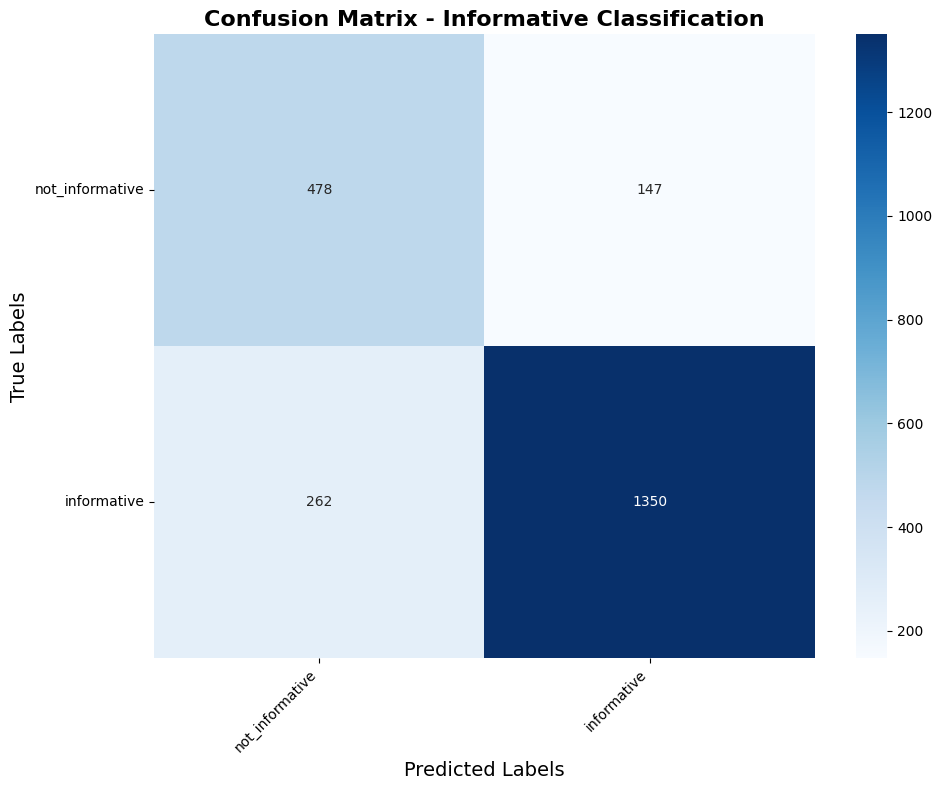

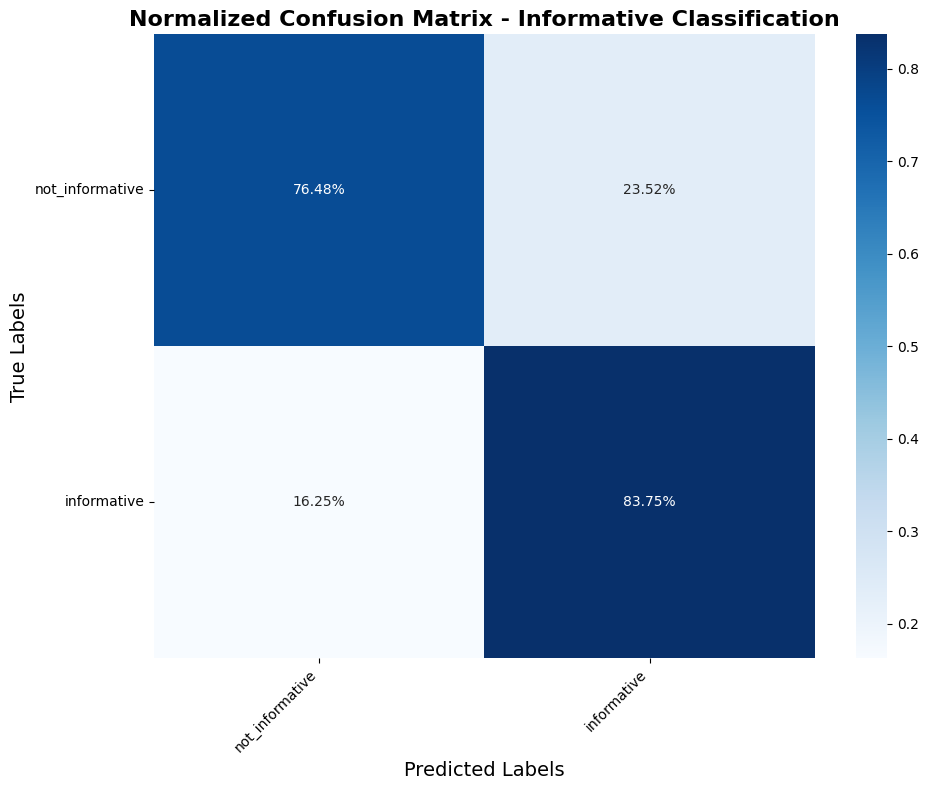


DETAILED CLASSIFICATION REPORT
                 precision    recall  f1-score   support

not_informative     0.6459    0.7648    0.7004       625
    informative     0.9018    0.8375    0.8684      1612

       accuracy                         0.8172      2237
      macro avg     0.7739    0.8011    0.7844      2237
   weighted avg     0.8303    0.8172    0.8215      2237


PER-CLASS ACCURACY ANALYSIS
not_informative          : 0.7648 (478/625 samples)
informative              : 0.8375 (1350/1612 samples)


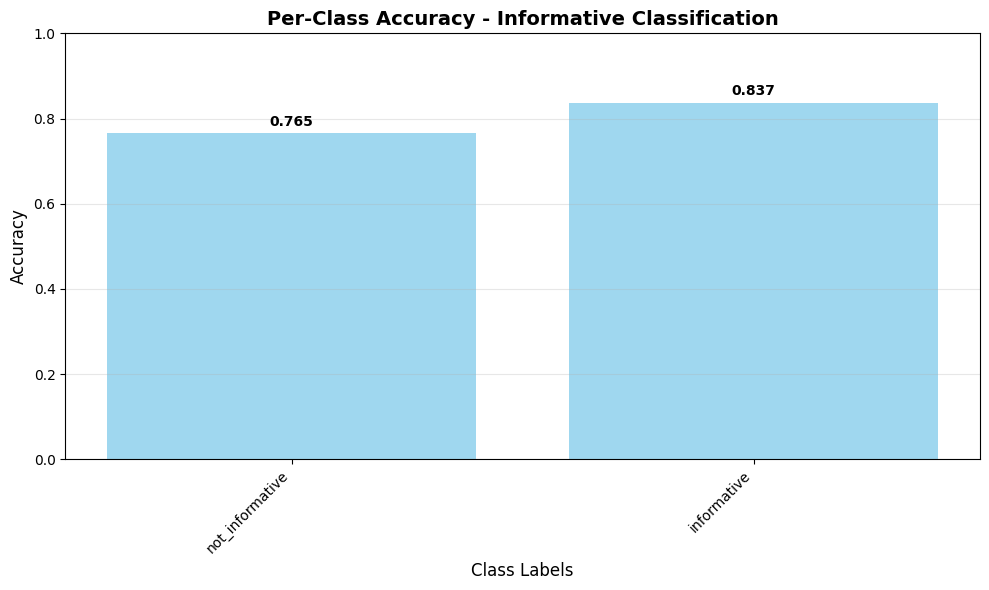


SUMMARY STATISTICS
Overall Test Accuracy: 0.8172
Best Performing Class: informative (0.8375)
Worst Performing Class: not_informative (0.7648)
Average Per-Class Accuracy: 0.8011
Standard Deviation: 0.0363

CLASS DISTRIBUTION IN TEST SET
not_informative          :  625 samples (27.9%)
informative              : 1612 samples (72.1%)

BINARY CLASSIFICATION METRICS
True Negatives:  478
False Positives: 147
False Negatives: 262
True Positives:  1350

Precision (Informative): 0.9018
Recall (Informative):    0.8375
Specificity:             0.7648
F1-Score:                0.8684


In [17]:
# Confusion Matrix and Detailed Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Function to get predictions for confusion matrix
def get_predictions(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Getting predictions'):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images, input_ids, attention_mask)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

# Get predictions for test set
print("Getting test set predictions...")
test_labels, test_preds = get_predictions(model, test_loader, device)

# Create label mapping for better visualization
label_map = {'not_informative': 0, 'informative': 1}
reverse_label_map = {v: k for k, v in label_map.items()}
class_names = [reverse_label_map[i] for i in range(len(label_map))]

# Create confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Detailed classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# Per-class accuracy analysis
print("\n" + "="*80)
print("PER-CLASS ACCURACY ANALYSIS")
print("="*80)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
for i, (class_name, accuracy) in enumerate(zip(class_names, class_accuracies)):
    total_samples = cm.sum(axis=1)[i]
    correct_samples = cm.diagonal()[i]
    print(f"{class_name:25}: {accuracy:.4f} ({correct_samples}/{total_samples} samples)")

# Plot per-class accuracy
plt.figure(figsize=(10, 6))
plt.bar(range(len(class_names)), class_accuracies, color='skyblue', alpha=0.8)
plt.xlabel('Class Labels', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy - Informative Classification', fontsize=14, fontweight='bold')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on top of bars
for i, accuracy in enumerate(class_accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
overall_accuracy = np.trace(cm) / np.sum(cm)
print(f"Overall Test Accuracy: {overall_accuracy:.4f}")
print(f"Best Performing Class: {class_names[np.argmax(class_accuracies)]} ({class_accuracies.max():.4f})")
print(f"Worst Performing Class: {class_names[np.argmin(class_accuracies)]} ({class_accuracies.min():.4f})")
print(f"Average Per-Class Accuracy: {class_accuracies.mean():.4f}")
print(f"Standard Deviation: {class_accuracies.std():.4f}")

# Class distribution analysis
print("\n" + "="*80)
print("CLASS DISTRIBUTION IN TEST SET")
print("="*80)
unique_test, counts_test = np.unique(test_labels, return_counts=True)
for label_idx, count in zip(unique_test, counts_test):
    class_name = reverse_label_map[label_idx]
    percentage = count / len(test_labels) * 100
    print(f"{class_name:25}: {count:4d} samples ({percentage:.1f}%)")

# Additional metrics for binary classification
print("\n" + "="*80)
print("BINARY CLASSIFICATION METRICS")
print("="*80)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Precision (Informative): {precision:.4f}")
print(f"Recall (Informative):    {recall:.4f}")
print(f"Specificity:             {specificity:.4f}")
print(f"F1-Score:                {f1_score:.4f}")

  warnings.warn(
                                                                  


1) Main Performance Table


,Accuracy,Precision_macro,Recall_macro,F1_macro
Full Model,0.8172,0.7739,0.8011,0.7844


  warnings.warn(
  warnings.warn(
  warnings.warn(
                                                                        


2) Ablation Table


...

/tmp/ipykernel_55/2684354134.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uncert_perf_df = u_df.groupby('bin').agg(


,bin,Samples,Accuracy,Uncertainty_mean
0,"(0.225, 0.437]",448,0.9420,0.3676
1,"(0.437, 0.521]",447,0.9128,0.4804
2,"(0.521, 0.588]",447,0.8523,0.5553
3,"(0.588, 0.659]",447,0.7987,0.6249
4,"(0.659, 0.693]",448,0.5804,0.6813


  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
                                                                  


6) Robustness Table


,Noise_std,Accuracy,F1_macro
0,0.00,0.8172,0.7844
1,0.01,0.8163,0.7835
2,0.03,0.8149,0.7824
3,0.05,0.8145,0.7821


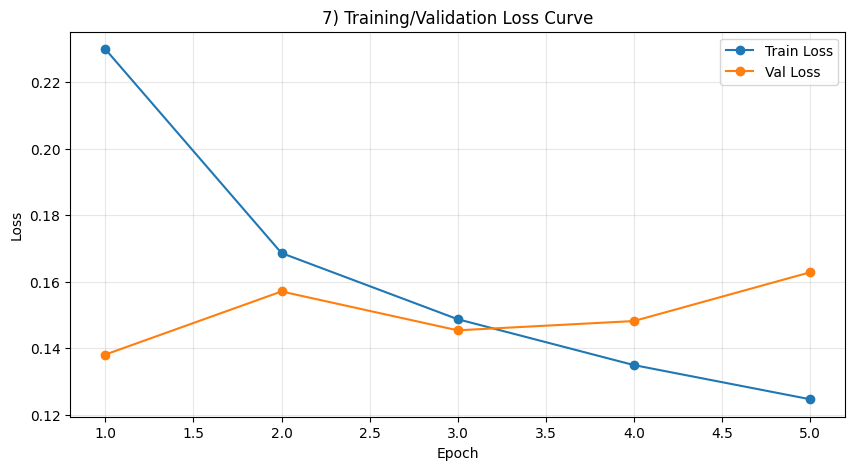

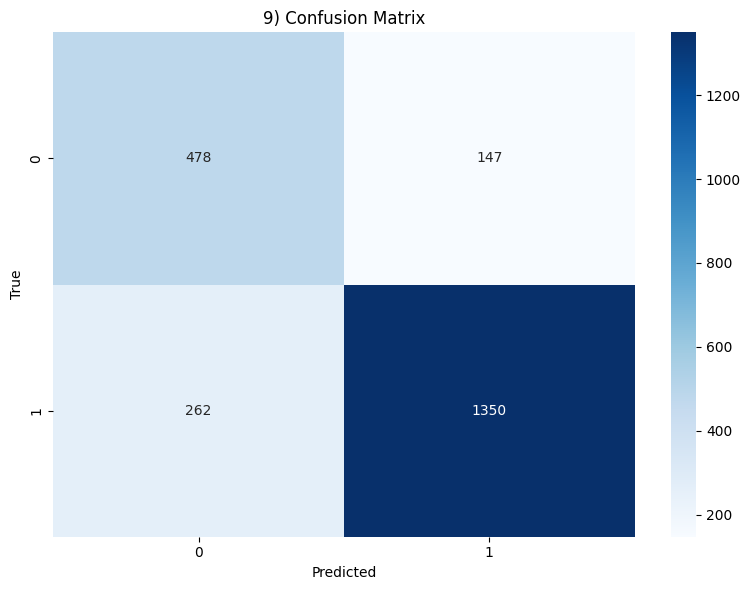

/tmp/ipykernel_55/2684354134.py:194: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Modality', y='Importance (Acc drop from full)', palette='viridis')


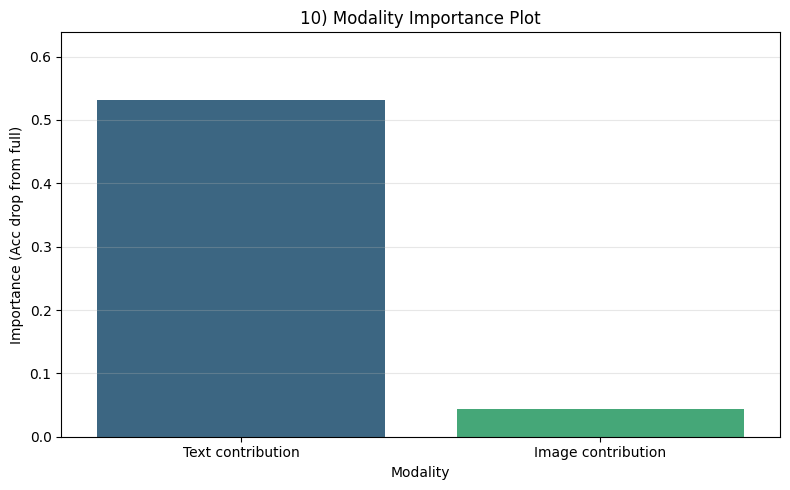

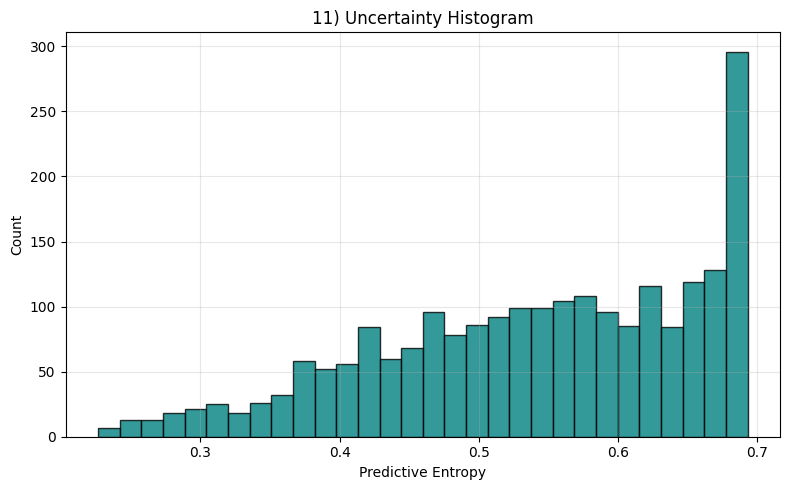

/tmp/ipykernel_55/2684354134.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_acc = c_df.groupby('bin').agg(


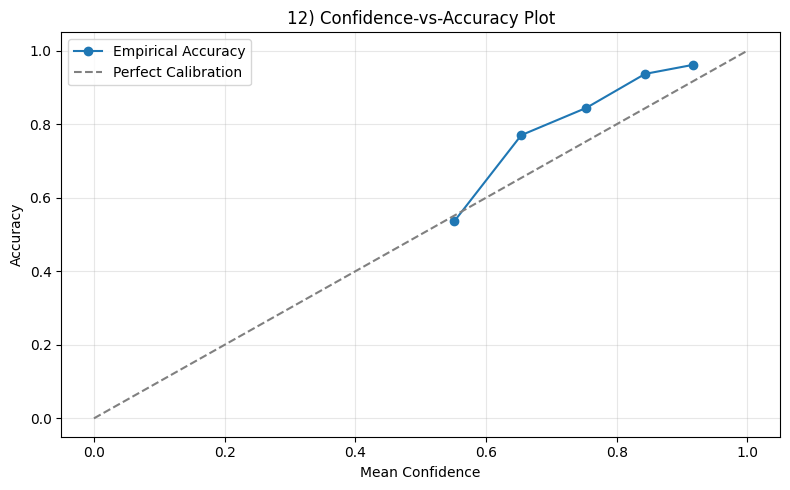

13) Attention Heatmap could not be generated: BertTokenizer has no attribute encode_plus

Results section completed.


In [18]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, f1_score
    )


def _forward_with_mode(model, images, input_ids, attention_mask, mode='full'):
    if mode == 'text_only':
        images = torch.zeros_like(images)
    elif mode == 'image_only':
        input_ids = torch.zeros_like(input_ids)
        attention_mask = torch.zeros_like(attention_mask)
    return model(images, input_ids, attention_mask)


@torch.no_grad()
def collect_predictions(model, loader, device, mode='full', max_batches=None, image_noise_std=0.0):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for b_idx, batch in enumerate(tqdm(loader, desc=f'Collecting ({mode})', leave=False), 1):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        if image_noise_std > 0:
            noise = torch.randn_like(images) * image_noise_std
            images = torch.clamp(images + noise, -3.0, 3.0)

        outputs = _forward_with_mode(model, images, input_ids, attention_mask, mode=mode)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        if max_batches is not None and b_idx >= max_batches:
            break

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def compute_summary_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_macro': p,
        'Recall_macro': r,
        'F1_macro': f1
    }


def print_table(title, df):
    print(f"\n{'=' * 90}\n{title}\n{'=' * 90}")
    display(df)


# 1) Main performance table (Full model on test set)
y_true_full, y_pred_full, y_prob_full = collect_predictions(model, test_loader, device, mode='full')
main_metrics = compute_summary_metrics(y_true_full, y_pred_full)
main_perf_df = pd.DataFrame([main_metrics], index=['Full Model'])
print_table('1) Main Performance Table', main_perf_df.round(4))


# 2) Ablation table
ablation_rows = []
for mode_name, mode in [('Full', 'full'), ('Text only', 'text_only'), ('Image only', 'image_only')]:
    y_t, y_p, _ = collect_predictions(model, test_loader, device, mode=mode)
    m = compute_summary_metrics(y_t, y_p)
    m['Setting'] = mode_name
    ablation_rows.append(m)
ablation_df = pd.DataFrame(ablation_rows).set_index('Setting')
print_table('2) Ablation Table', ablation_df.round(4))


# 3) Per-class metrics table
per_class_report = classification_report(
    y_true_full, y_pred_full, output_dict=True, zero_division=0
    )
per_class_df = pd.DataFrame(per_class_report).T
per_class_df = per_class_df[~per_class_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
print_table('3) Per-Class Metrics Table', per_class_df.round(4))


# 4) Uncertainty-performance table
eps = 1e-12
uncertainty = -np.sum(y_prob_full * np.log(y_prob_full + eps), axis=1)
confidence = np.max(y_prob_full, axis=1)
correct = (y_true_full == y_pred_full).astype(int)
u_df = pd.DataFrame({'uncertainty': uncertainty, 'correct': correct})
u_df['bin'] = pd.qcut(u_df['uncertainty'], q=5, duplicates='drop')
uncert_perf_df = u_df.groupby('bin').agg(
    Samples=('correct', 'count'),
    Accuracy=('correct', 'mean'),
    Uncertainty_mean=('uncertainty', 'mean')
).reset_index()
print_table('4) Uncertainty-Performance Table', uncert_perf_df.round(4))


# 5) Efficiency table (approximate benchmark on subset)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = (n_params * 4) / (1024 ** 2)

bench_batches = 20
start = time.time()
_ = collect_predictions(model, test_loader, device, mode='full', max_batches=bench_batches)
elapsed = time.time() - start
samples_bench = min(len(test_dataset), bench_batches * test_loader.batch_size)
ms_per_sample = (elapsed * 1000.0) / max(samples_bench, 1)
throughput = samples_bench / max(elapsed, 1e-9)

efficiency_df = pd.DataFrame([{
    'Total_params': n_params,
    'Trainable_params': n_trainable,
    'Approx_model_size_MB': model_size_mb,
    'Latency_ms_per_sample': ms_per_sample,
    'Throughput_samples_per_sec': throughput
}])
print_table('5) Efficiency Table', efficiency_df.round(4))


# 6) Robustness table (image noise stress test)
robust_rows = []
for sigma in [0.00, 0.01, 0.03, 0.05]:
    y_t, y_p, _ = collect_predictions(
        model, test_loader, device, mode='full', image_noise_std=sigma
    )
    robust_rows.append({
        'Noise_std': sigma,
        'Accuracy': accuracy_score(y_t, y_p),
        'F1_macro': f1_score(y_t, y_p, average='macro')
    })
robustness_df = pd.DataFrame(robust_rows)
print_table('6) Robustness Table', robustness_df.round(4))


# 7) Training/validation loss curve
if 'train_losses' in globals() and 'val_losses' in globals() and len(train_losses) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train Loss')
    plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Val Loss')
    plt.title('7) Training/Validation Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# 8) Training/validation F1 curve
if 'train_f1s' in globals() and 'val_f1s' in globals() and len(train_f1s) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_f1s) + 1), train_f1s, marker='o', label='Train F1 (macro)')
    plt.plot(range(1, len(val_f1s) + 1), val_f1s, marker='o', label='Val F1 (macro)')
    plt.title('8) Training/Validation F1 Curve')
    plt.xlabel('Epoch')
    plt.ylabel('F1-score')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# 9) Confusion matrix
cm = confusion_matrix(y_true_full, y_pred_full)
class_names = sorted(list(set(y_true_full.tolist())))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('9) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# 10) Modality importance plots
full_acc = ablation_df.loc['Full', 'Accuracy']
text_only_acc = ablation_df.loc['Text only', 'Accuracy']
image_only_acc = ablation_df.loc['Image only', 'Accuracy']
importance_df = pd.DataFrame({
    'Modality': ['Text contribution', 'Image contribution'],
    'Importance (Acc drop from full)': [
        max(full_acc - image_only_acc, 0),
        max(full_acc - text_only_acc, 0)
    ]
})
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Modality', y='Importance (Acc drop from full)', palette='viridis')
plt.title('10) Modality Importance Plot')
plt.ylim(0, max(importance_df['Importance (Acc drop from full)'].max() * 1.2, 0.05))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 11) Uncertainty histogram
plt.figure(figsize=(8, 5))
plt.hist(uncertainty, bins=30, color='teal', alpha=0.8, edgecolor='black')
plt.title('11) Uncertainty Histogram')
plt.xlabel('Predictive Entropy')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 12) Confidence-vs-accuracy plot
c_df = pd.DataFrame({'confidence': confidence, 'correct': correct})
c_df['bin'] = pd.cut(c_df['confidence'], bins=np.linspace(0, 1, 11), include_lowest=True)
conf_acc = c_df.groupby('bin').agg(
    Accuracy=('correct', 'mean'),
    MeanConfidence=('confidence', 'mean'),
    Samples=('correct', 'count')
).reset_index()
plt.figure(figsize=(8, 5))
plt.plot(conf_acc['MeanConfidence'], conf_acc['Accuracy'], marker='o', label='Empirical Accuracy')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')
plt.title('12) Confidence-vs-Accuracy Plot')
plt.xlabel('Mean Confidence')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 13) Attention heatmap (BERT final layer CLS attention over tokens)
try:
    sample_text = str(test_df.iloc[0]['tweet_text'])
    enc = tokenizer.encode_plus(
        sample_text,
        add_special_tokens=True,
        max_length=64,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
    in_ids = enc['input_ids'].to(device)
    attn_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        attn_out = model.text_encoder(
            input_ids=in_ids, attention_mask=attn_mask, output_attentions=True
        )

    # transformers v2.x: attentions are usually last item in output tuple
    attentions = attn_out[-1] if isinstance(attn_out, (tuple, list)) else None
    if attentions is not None and len(attentions) > 0:
        last_layer = attentions[-1][0]  # [heads, seq, seq]
        cls_to_tokens = last_layer[:, 0, :].mean(dim=0).cpu().numpy()
        tokens = tokenizer.convert_ids_to_tokens(in_ids[0].cpu().numpy())

        valid_len = int(attn_mask[0].sum().item())
        cls_to_tokens = cls_to_tokens[:valid_len]
        tokens = tokens[:valid_len]

        plt.figure(figsize=(min(18, 0.35 * len(tokens) + 4), 3.5))
        sns.heatmap(
            cls_to_tokens.reshape(1, -1),
            cmap='magma',
            cbar=True,
            xticklabels=tokens,
            yticklabels=['CLS attention']
        )
        plt.title('13) Attention Heatmap (BERT CLS -> Tokens)')
        plt.xticks(rotation=60, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print('13) Attention Heatmap: attentions are not available from this model output.')
except Exception as e:
    print(f'13) Attention Heatmap could not be generated: {e}')

print('\nResults section completed.')

## 8. GMU Gate Analysis — Modality Balance Verification

Visualise the per-sample gate values to confirm that text and image are both contributing meaningfully to classification decisions.

Gate analysis:   0%|          | 0/70 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Mean gate (text weight)  across test set: 0.504
Mean gate (image weight) across test set: 0.496


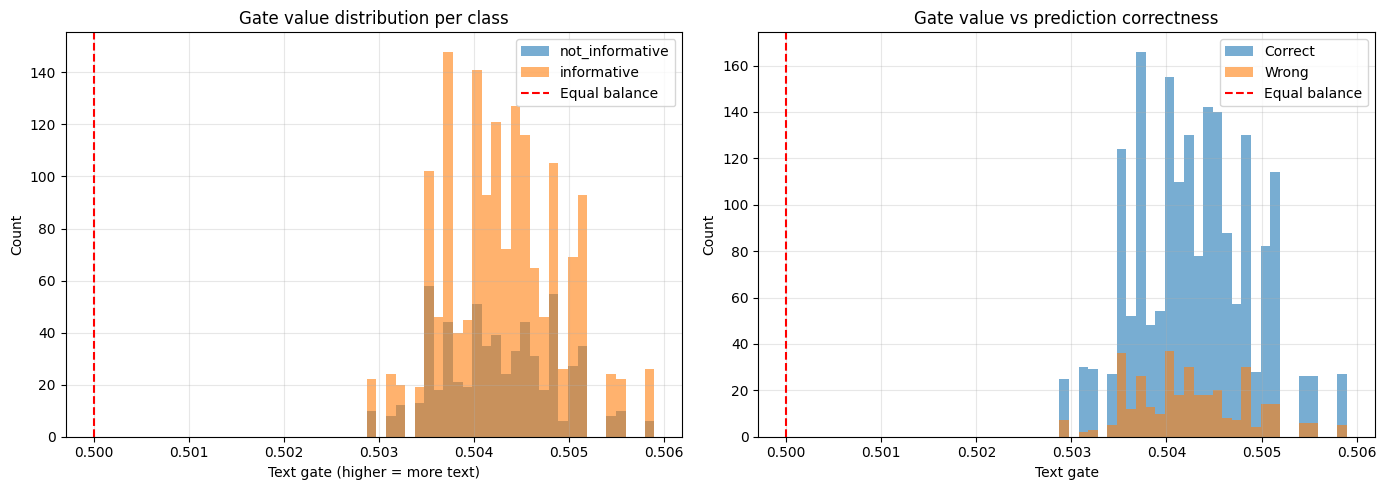

  not_informative            →  avg text gate=0.504  img gate=0.496
  informative                →  avg text gate=0.504  img gate=0.496

If both gates are near 0.5, text and image contribute equally ✓


In [19]:
# ── Collect gate values on the test set ──────────────────────────────────
model.eval()
all_gates, all_labels_g, all_correct_g = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Gate analysis', leave=False):
        images    = batch['image'].to(device)
        inp_ids   = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['label'].to(device)

        logits, _ = model(images, inp_ids, attn_mask, return_alignment=True)
        gate_val  = model.last_gate_mean   # scalar mean gate for this batch
        preds     = (torch.softmax(logits, dim=1)[:, 1] >= best_thresh).long()

        all_gates.extend([gate_val] * labels.size(0))
        all_labels_g.extend(labels.cpu().numpy())
        all_correct_g.extend(preds.eq(labels).cpu().numpy())

all_gates     = np.array(all_gates)
all_labels_g  = np.array(all_labels_g)
all_correct_g = np.array(all_correct_g)

print(f"Mean gate (text weight)  across test set: {all_gates.mean():.3f}")
print(f"Mean gate (image weight) across test set: {1 - all_gates.mean():.3f}")

# Gate distribution per class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cls_idx, cls_name in [(0, 'not_informative'), (1, 'informative')]:
    mask = all_labels_g == cls_idx
    axes[0].hist(all_gates[mask], bins=30, alpha=0.6, label=cls_name)
axes[0].axvline(0.5, ls='--', color='red', label='Equal balance')
axes[0].set(title='Gate value distribution per class',
            xlabel='Text gate (higher = more text)', ylabel='Count')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Gate vs correctness
axes[1].hist(all_gates[all_correct_g == 1], bins=30, alpha=0.6, label='Correct')
axes[1].hist(all_gates[all_correct_g == 0], bins=30, alpha=0.6, label='Wrong')
axes[1].axvline(0.5, ls='--', color='red', label='Equal balance')
axes[1].set(title='Gate value vs prediction correctness',
            xlabel='Text gate', ylabel='Count')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/gate_analysis.png', dpi=120)
plt.show()

# Summary
for cls_idx, cls_name in [(0, 'not_informative'), (1, 'informative')]:
    mask  = all_labels_g == cls_idx
    tg    = all_gates[mask].mean()
    print(f"  {cls_name:25s}  →  avg text gate={tg:.3f}  img gate={1-tg:.3f}")
print("\nIf both gates are near 0.5, text and image contribute equally ✓")
